# Vásárlói adathalmaz – Kávézó

Ez az adathalmaz egy kávézó valós vásárlóit reprezentálja.  
Minden sor egy egyedi vásárlót jelöl, a következő oszlopokkal:

- **Életkor** – a vásárló életkora (év)  
- **Havi_látogatás** – a havi látogatások száma  
- **Átlagos_költés** – átlagos költés egy látogatás során (USD)  
- **Név** – a vásárló neve  


## 1. feladat

Olvassátok be az `klaszter_orai_feladat_2d.csv` fájlt egy DataFrame-be.  
Ellenőrizzétek az oszlopok adattípusát, és szükség esetén állítsátok be a megfelelő típusokat:  

- **Életkor** és **Havi_látogatás** legyen egész szám (`int`)  
- **Átlagos_költés** legyen lebegőpontos (`float`)  
- **Név** legyen szöveg (`string/object`)  

Ezután nézzétek meg az adatok első néhány sorát, és győződjetek meg róla, hogy minden helyes.

In [7]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans

df = pd.read_csv('klaszter_orai_feladat_2d.csv')
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Életkor         150 non-null    int64  
 1   Havi_látogatás  150 non-null    int64  
 2   Átlagos_költés  150 non-null    float64
 3   Név             150 non-null    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 4.8+ KB


,Életkor,Havi_látogatás,Átlagos_költés,Név
0,25,3,13.238443,Feri Nagy
1,29,3,8.829315,Júlia Tóth
2,29,4,7.652628,Bence Szabó
3,26,2,7.671351,Hanna Nagy
4,25,0,1.375411,Gábor Kovács


## 2. feladat

Hozzatok létre egy új DataFrame-et, ami csak a **Havi_látogatás** és az **Átlagos_költés** oszlopokat tartalmazza.  
Mentés előtt ellenőrizzétek az új DataFrame-et, hogy csak a kívánt oszlopok legyenek benne.

In [11]:
df_visits_purchase = df[['Havi_látogatás', 'Átlagos_költés']]
df_visits_purchase.head(5)

,Havi_látogatás,Átlagos_költés
0,3,13.238443
1,3,8.829315
2,4,7.652628
3,2,7.671351
4,0,1.375411


## 3. feladat

Határozzátok meg az optimális klaszterszámot a **könyökmódszer** segítségével a `df_visits_purchase` DataFrame-en.  

- A for ciklus 1-től 6-ig fusson, minden klaszterszámra számoljuk ki a KMeans **inertia_** értékét.  
- Rajzoljátok ki az eredményt **vonaldiagram** és **pontdiagram** segítségével.  
- A pontdiagram pontjai legyenek **zöld színűek**.

[[1.00000000e+00 3.84952037e+04]
 [2.00000000e+00 1.07286027e+04]
 [3.00000000e+00 3.72101080e+03]
 [4.00000000e+00 2.74269700e+03]
 [5.00000000e+00 2.16564716e+03]
 [6.00000000e+00 1.60209539e+03]]


C:\Users\student\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\student\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\student\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\student\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory le

<Axes: >

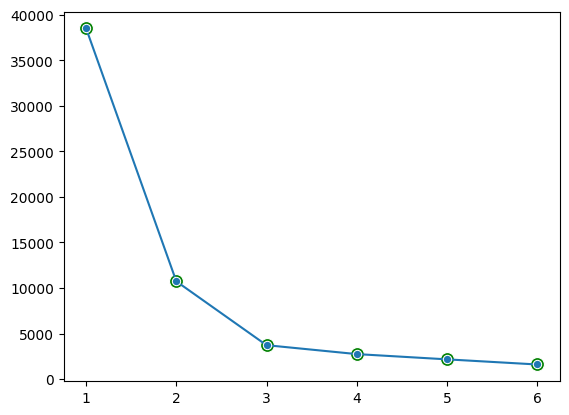

In [16]:
err = []
for i in range(1,7):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df_visits_purchase)
    err.append([kmeans.n_clusters, kmeans.inertia_])

err = np.asarray(err)
print(err)

sns.lineplot(x=err[:,0], y=err[:,1], marker='o')
sns.scatterplot(x=err[:,0], y=err[:,1], color='green', s=100)

## 4. feladat

- Hozz létre egy változót `kmeans_2d` néven, amely a **KMeans modellt** tartalmazza az optimális klaszterszámmal (a 3. feladat alapján).  
- Tanítsd be a `df_visits_purchase` adatokon.  
- Vizualizáld az eredményt 2D scatter plot segítségével, ahol minden pont színe a hozzá tartozó klasztert jelzi.  
- A **klaszterközéppontok (centroidok) is legyenek feltűntetve**, például nagyobb, piros jelöléssel a scatteren.

C:\Users\student\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


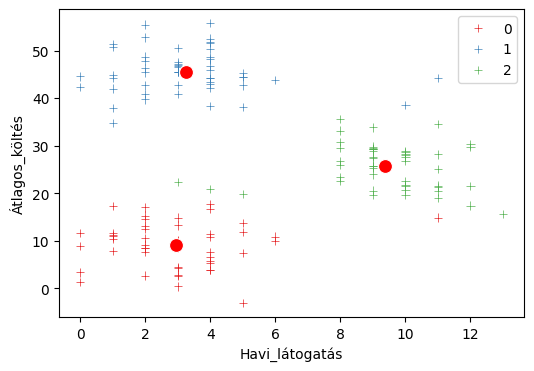

In [18]:
kmeans_2d = KMeans(n_clusters=3)
kmeans_2d.fit(df_visits_purchase);

kmeans_2d.cluster_centers_

def plot_result(kmeans_2d):
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df_visits_purchase['Havi_látogatás'], y=df_visits_purchase['Átlagos_költés'], hue=kmeans_2d.labels_, palette="Set1", marker='+');
    sns.scatterplot(x=kmeans_2d.cluster_centers_[:,0], y=kmeans_2d.cluster_centers_[:,1], marker='o', s=100, c=['red']);

plot_result(kmeans_2d)

## 5. feladat

- Hozz létre egy új KMeans klaszterezőt `kmeans_3d` néven, most a **három numerikus oszlop** (`Életkor`, `Havi_látogatás`, `Átlagos_költés`) alapján.  
- A klaszterszám legyen **3**.  
- Tanítsd be a modellt, majd ábrázold az eredményt **3D scatter plot** segítségével, ahol a pontok színe a klasztereket jelzi, és a **klaszterközéppontok is megjelennek**.

C:\Users\student\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


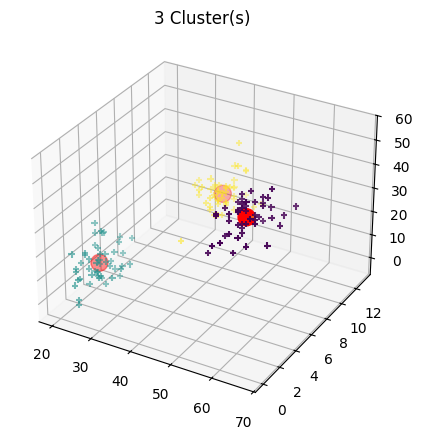

In [20]:
from mpl_toolkits.mplot3d import Axes3D

kmeans_3d = KMeans(n_clusters=3)
kmeans_3d.fit(df[['Életkor', 'Havi_látogatás', 'Átlagos_költés']]);

def plot_result_3d(kmeans_3d):
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df['Életkor'], df['Havi_látogatás'], df['Átlagos_költés'], c=kmeans_3d.labels_, marker='+')
    ax.scatter(kmeans_3d.cluster_centers_[:,0],
               kmeans_3d.cluster_centers_[:,1],
               kmeans_3d.cluster_centers_[:,2],
               c='red', s=150)
    ax.set_title(f"{kmeans_3d.n_clusters} Cluster(s)")
    plt.show()

plot_result_3d(kmeans_3d)